In [1]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import missingno as msno
import math

In [3]:
df = pd.read_csv('../data/house_price.csv')
print("Data loaded successfully")

Data loaded successfully


In [4]:
df.head

<bound method NDFrame.head of      Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0              1360             2              1        1981  0.599637   
1              4272             3              3        2016  4.753014   
2              3592             1              2        2016  3.634823   
3               966             1              2        1977  2.730667   
4              4926             2              1        1993  4.699073   
..              ...           ...            ...         ...       ...   
995            3261             4              1        1978  2.165110   
996            3179             1              2        1999  2.977123   
997            2606             4              2        1962  4.055067   
998            4723             5              2        1950  1.930921   
999            3268             4              2        1983  3.108790   

     Garage_Size  Neighborhood_Quality   House_Price  
0              0          

In [5]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [6]:
df.describe

<bound method NDFrame.describe of      Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0              1360             2              1        1981  0.599637   
1              4272             3              3        2016  4.753014   
2              3592             1              2        2016  3.634823   
3               966             1              2        1977  2.730667   
4              4926             2              1        1993  4.699073   
..              ...           ...            ...         ...       ...   
995            3261             4              1        1978  2.165110   
996            3179             1              2        1999  2.977123   
997            2606             4              2        1962  4.055067   
998            4723             5              2        1950  1.930921   
999            3268             4              2        1983  3.108790   

     Garage_Size  Neighborhood_Quality   House_Price  
0              0      

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
duplicate_count = df.duplicated().sum()

total_rows = len(df)
non_duplicate_count = total_rows - duplicate_count

In [9]:
duplicate_percentage = (duplicate_count / total_rows) * 100 if total_rows else 0
non_duplicate_percentage = 100 - duplicate_percentage

In [10]:
duplicate_summary = pd.DataFrame({
    'Any Duplicates?': [duplicate_count > 0],
    'Number of Duplicates': [duplicate_count],
    'Duplicate Percentage (%)': [duplicate_percentage],
    'Non-Duplicate Percentage (%)': [non_duplicate_percentage]
})
print("Duplicate Summary:")
display(duplicate_summary)

Duplicate Summary:


,Any Duplicates?,Number of Duplicates,Duplicate Percentage (%),Non-Duplicate Percentage (%)
0,False,0,0.0,100.0


In [11]:
if duplicate_count > 0:
    duplicate_rows = df[df.duplicated(keep=False)]
    print("\nDuplicate Records:")
    display(duplicate_rows)
else:
    print("\nNo duplicate records to display.")


No duplicate records to display.


In [12]:
labels = ['Duplicates', 'Non-Duplicates']
counts = [duplicate_count, non_duplicate_count]
percentages = [duplicate_percentage, non_duplicate_percentage]

<function matplotlib.pyplot.xlabel(xlabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['left', 'center', 'right'] | None" = None, **kwargs) -> 'Text'>

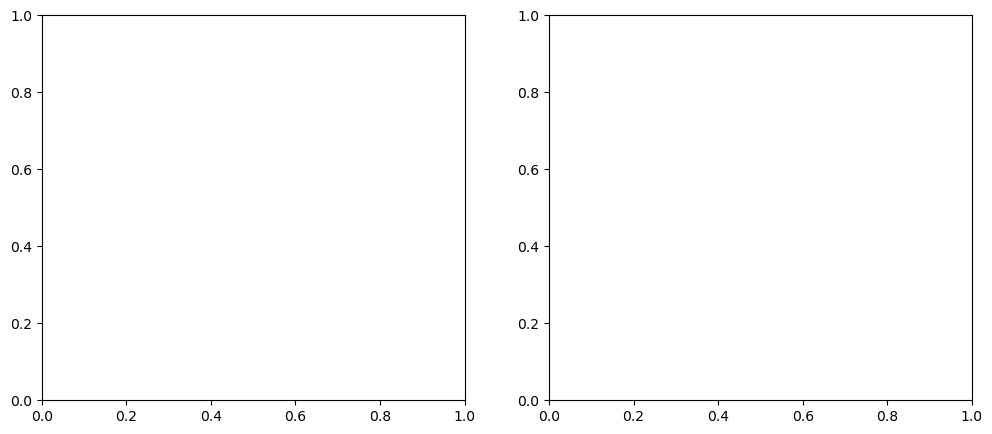

In [13]:
# --- Create side-by-side plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt. xlabel

In [14]:
# 1) Bar chart (counts)
axes[0].bar(labels, counts)
axes[0].set_title('Count of Duplicate vs Non-Duplicate Rows')
axes[0].set_ylabel('Number of Rows')
# Annotate bars with count values
for i, v in enumerate(counts):
    axes[0].text(i, v + max(counts) * 0.01, str(v), ha='center', va='bottom')

In [15]:
# 2) Pie chart (percentages)
# Add labels with both category name and percentage
pie_labels = [f'{lab} ({pct:.2f}%)' for lab, pct in zip(labels, percentages)]
axes[1].pie(counts, labels=pie_labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Duplicate vs Non-Duplicate Percentage')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [16]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [17]:
missing_summary = pd.DataFrame({
    'Feature': df.columns,
    'Any Null?': df.isnull().any().values,
    'Null Count': df.isnull().sum().values,
    'Null Percentage (%)': (df.isnull().sum().values / len(df)) * 100,
    'Non-Null Count': df.notnull().sum().values,
    'Non-Null Percentage (%)': (df.notnull().sum().values / len(df)) * 100
})
display(missing_summary)

,Feature,Any Null?,Null Count,Null Percentage (%),Non-Null Count,Non-Null Percentage (%)
0,Square_Footage,False,0,0.0,1000,100.0
1,Num_Bedrooms,False,0,0.0,1000,100.0
2,Num_Bathrooms,False,0,0.0,1000,100.0
3,Year_Built,False,0,0.0,1000,100.0
4,Lot_Size,False,0,0.0,1000,100.0
5,Garage_Size,False,0,0.0,1000,100.0
6,Neighborhood_Quality,False,0,0.0,1000,100.0
7,House_Price,False,0,0.0,1000,100.0


In [18]:
total_cells = df.size
total_nulls = df.isnull().sum().sum()
total_non_nulls = total_cells - total_nulls

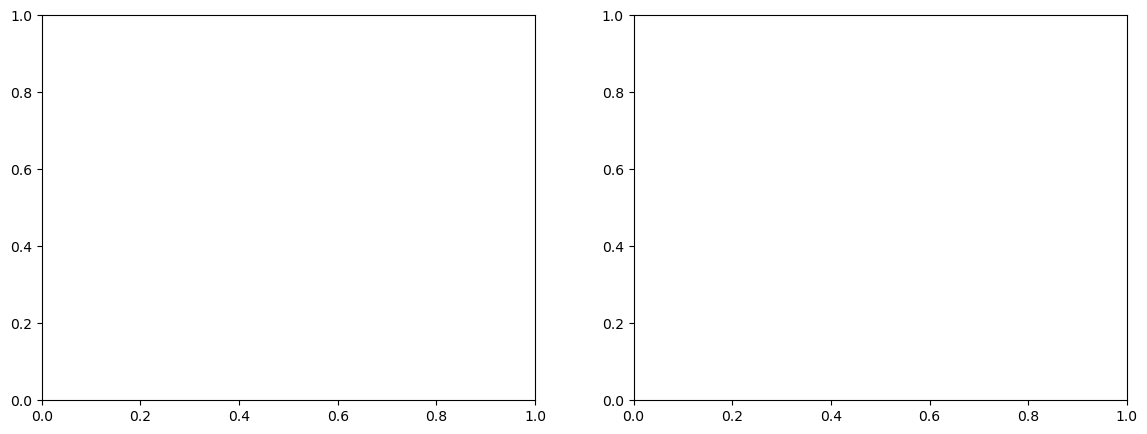

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [20]:
labels = ['Null Cells', 'Non-Null Cells']
counts = [total_nulls, total_non_nulls]
axes[0].bar(labels, counts)
axes[0].set_title('Total Null vs Non-Null Cells (Counts)')
axes[0].set_ylabel('Number of Cells')
for i, v in enumerate(counts):
    axes[0].text(i, v + max(counts)*0.01, str(int(v)), ha='center', va='bottom')

In [21]:
percentages = [(c / total_cells) * 100 for c in counts]
pie_labels = [f'{lab} ({pct:.2f}%)' for lab, pct in zip(labels, percentages)]
axes[1].pie(counts, labels=pie_labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Total Null vs Non-Null Cells (Percentage)')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [22]:
cols = df.columns.tolist()
null_counts = df.isnull().sum().values
non_null_counts = df.notnull().sum().values

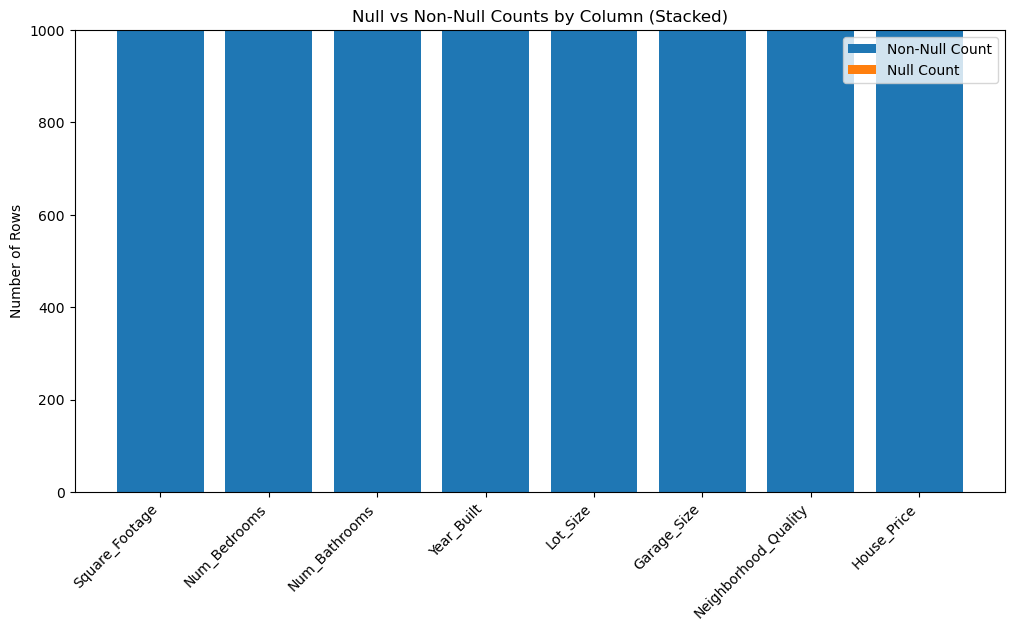

In [23]:
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(cols))
    ax.bar(x, non_null_counts, label='Non-Null Count')
    ax.bar(x, null_counts, bottom=non_null_counts, label='Null Count')
    ax.set_xticks(x)
    ax.set_xticklabels(cols, rotation=45, ha='right')
    ax.set_ylabel('Number of Rows')
    ax.set_title('Null vs Non-Null Counts by Column (Stacked)')
    ax.legend()

In [24]:
for i in range(len(cols)):
    total_val = non_null_counts[i] + null_counts[i]
    ax.text(i, total_val + max(total_val*0.01, 1), str(int(total_val)),
                ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [25]:
    n_cols = 3  
    n_plots = len(cols)
    n_rows = math.ceil(n_plots / n_cols)

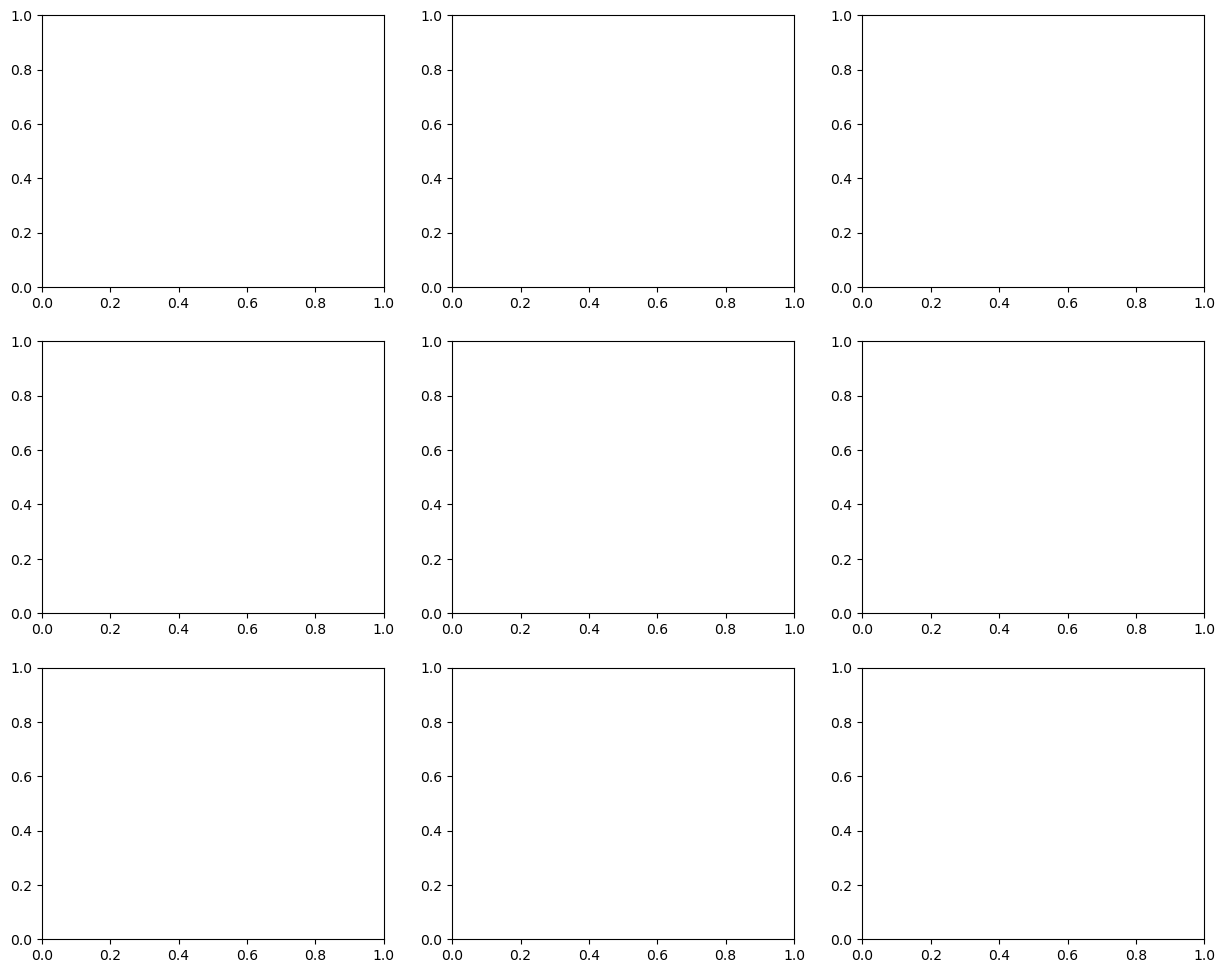

In [26]:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

In [27]:
for i, col in enumerate(cols):
        ax = axes[i]
        col_null = int(null_counts[i])
        col_non_null = int(non_null_counts[i])
        total = col_null + col_non_null

In [28]:
        values = [col_null, col_non_null]
        pct_null = (col_null / total) * 100
        pct_non_null = (col_non_null / total) * 100

In [29]:
donut_labels = [
            f'Null ({pct_null:.2f}%)',
            f'Non-Null ({pct_non_null:.2f}%)'
        ]

In [30]:
ax.pie(values, labels=donut_labels, autopct='%1.1f%%',
startangle=90, wedgeprops={'width': 0.4})
ax.set_title(f'Null vs Non-Null % — {col}')
ax.axis('equal')

(np.float64(-1.1), np.float64(1.1), np.float64(-1.1), np.float64(1.1))

In [31]:
for j in range(n_plots, n_rows*n_cols):
        axes[j].axis('off')
        plt.tight_layout()
        plt.show()

else:
    print("\nNo column-level null values. Column-based charts skipped.")

<Figure size 640x480 with 0 Axes>


No column-level null values. Column-based charts skipped.


In [32]:
df_cont = df.select_dtypes(include=["int64", "float64"]).columns
print(df_cont)

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')


In [35]:
df_cont = [
    'Square_Footage',
    'Num_Bedrooms',
    'Num_Bathrooms',
    'Year_Built',
    'Lot_Size',
    'Garage_Size',
    'Neighborhood_Quality',
    'House_Price'
]

summary_list = []

In [36]:
for col in df_cont:  # Correct iteration
    data = df[col]
    
    mini = data.min()
    maxi = data.max()
    rangi = maxi - mini
    mean = data.mean()
    median = data.median()
    mode_formula = round(3 * median - 2 * mean, 3)  # Pearson's Mode
    
    std_dev = data.std()
    variance = data.var()
    skewness = data.skew()
    kurt = data.kurtosis()
    
    q1 = data.quantile(0.25)
    q2 = data.quantile(0.50)
    q3 = data.quantile(0.75)
    
    any_zero = (data == 0).any()
    any_positive = (data > 0).any()
    any_negative = (data < 0).any()
    
    summary_list.append({
        'Feature': col,
        'Min': mini,
        'Max': maxi,
        'Range': rangi,
        'Mean': mean,
        'Median': median,
        'Mode_rel': mode_formula,
        'Std Dev': round(std_dev, 3),
        'Variance': round(variance, 3),
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurt, 3),
        'Q1': round(q1, 3),
        'Q2': round(q2, 3),
        'Q3': round(q3, 3),
        'Any Zero?': any_zero,
        'Any Positive?': any_positive,
        'Any Negative?': any_negative
    })

In [37]:
distribution_summary = pd.DataFrame(summary_list)

# Display all columns
pd.set_option('display.max_columns', None)
display(distribution_summary)


import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

for col in df_cont:
    data = df[col].dropna()

    print(f"\n======================== {col} ========================\n")

,Feature,Min,Max,Range,Mean,Median,Mode_rel,Std Dev,Variance,Skewness,Kurtosis,Q1,Q2,Q3,Any Zero?,Any Positive?,Any Negative?
0,Square_Footage,503.000000,4.999000e+03,4496.000000,2815.422000,2862.500000,2956.656,1255.515,1.576318e+06,-0.066,-1.128,1749.500,2862.500,3849.500,False,True,False
1,Num_Bedrooms,1.000000,5.000000e+00,4.000000,2.990000,3.000000,3.020,1.428,2.038000e+00,0.026,-1.334,2.000,3.000,4.000,False,True,False
2,Num_Bathrooms,1.000000,3.000000e+00,2.000000,1.973000,2.000000,2.054,0.820,6.730000e-01,0.050,-1.512,1.000,2.000,3.000,False,True,False
3,Year_Built,1950.000000,2.022000e+03,72.000000,1986.550000,1986.000000,1984.900,20.633,4.257170e+02,-0.021,-1.185,1969.000,1986.000,2004.250,False,True,False
4,Lot_Size,0.506058,4.989303e+00,4.483244,2.778087,2.809740,2.873,1.298,1.685000e+00,-0.044,-1.201,1.666,2.810,3.923,False,True,False
5,Garage_Size,0.000000,2.000000e+00,2.000000,1.022000,1.000000,0.956,0.815,6.640000e-01,-0.040,-1.493,0.000,1.000,2.000,True,True,False
6,Neighborhood_Quality,1.000000,1.000000e+01,9.000000,5.615000,6.000000,6.770,2.887,8.335000e+00,-0.020,-1.206,3.000,6.000,8.000,False,True,False
7,House_Price,111626.853424,1.108237e+06,996609.982868,618861.018647,628267.291129,647079.836,253568.058,6.429676e+10,-0.064,-1.091,401648.229,628267.291,827141.278,False,True,False



======================== Square_Footage ========================


======================== Num_Bedrooms ========================


======================== Num_Bathrooms ========================


======================== Year_Built ========================


======================== Lot_Size ========================


======================== Garage_Size ========================


======================== Neighborhood_Quality ========================


======================== House_Price ========================



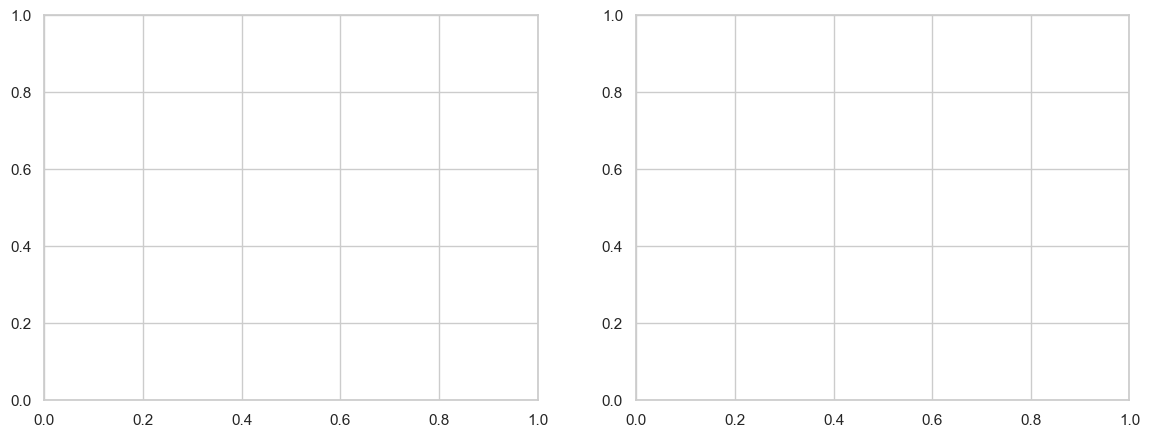

In [39]:
# Create 1 row → 2 columns layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [41]:
    sns.kdeplot(data, fill=True, ax=axes[0])
    sns.rugplot(data, height=0.1, ax=axes[0])
    axes[0].set_title(f"KDE + Rug Plot for {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Density")

Text(4.444444444444459, 0.5, 'Density')

In [43]:
    sns.histplot(data, kde=True, bins=20, ax=axes[1])
    axes[1].set_title(f"KDE + Histogram Plot for {col}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


    sns.set(style="ticks")

<Figure size 640x480 with 0 Axes>

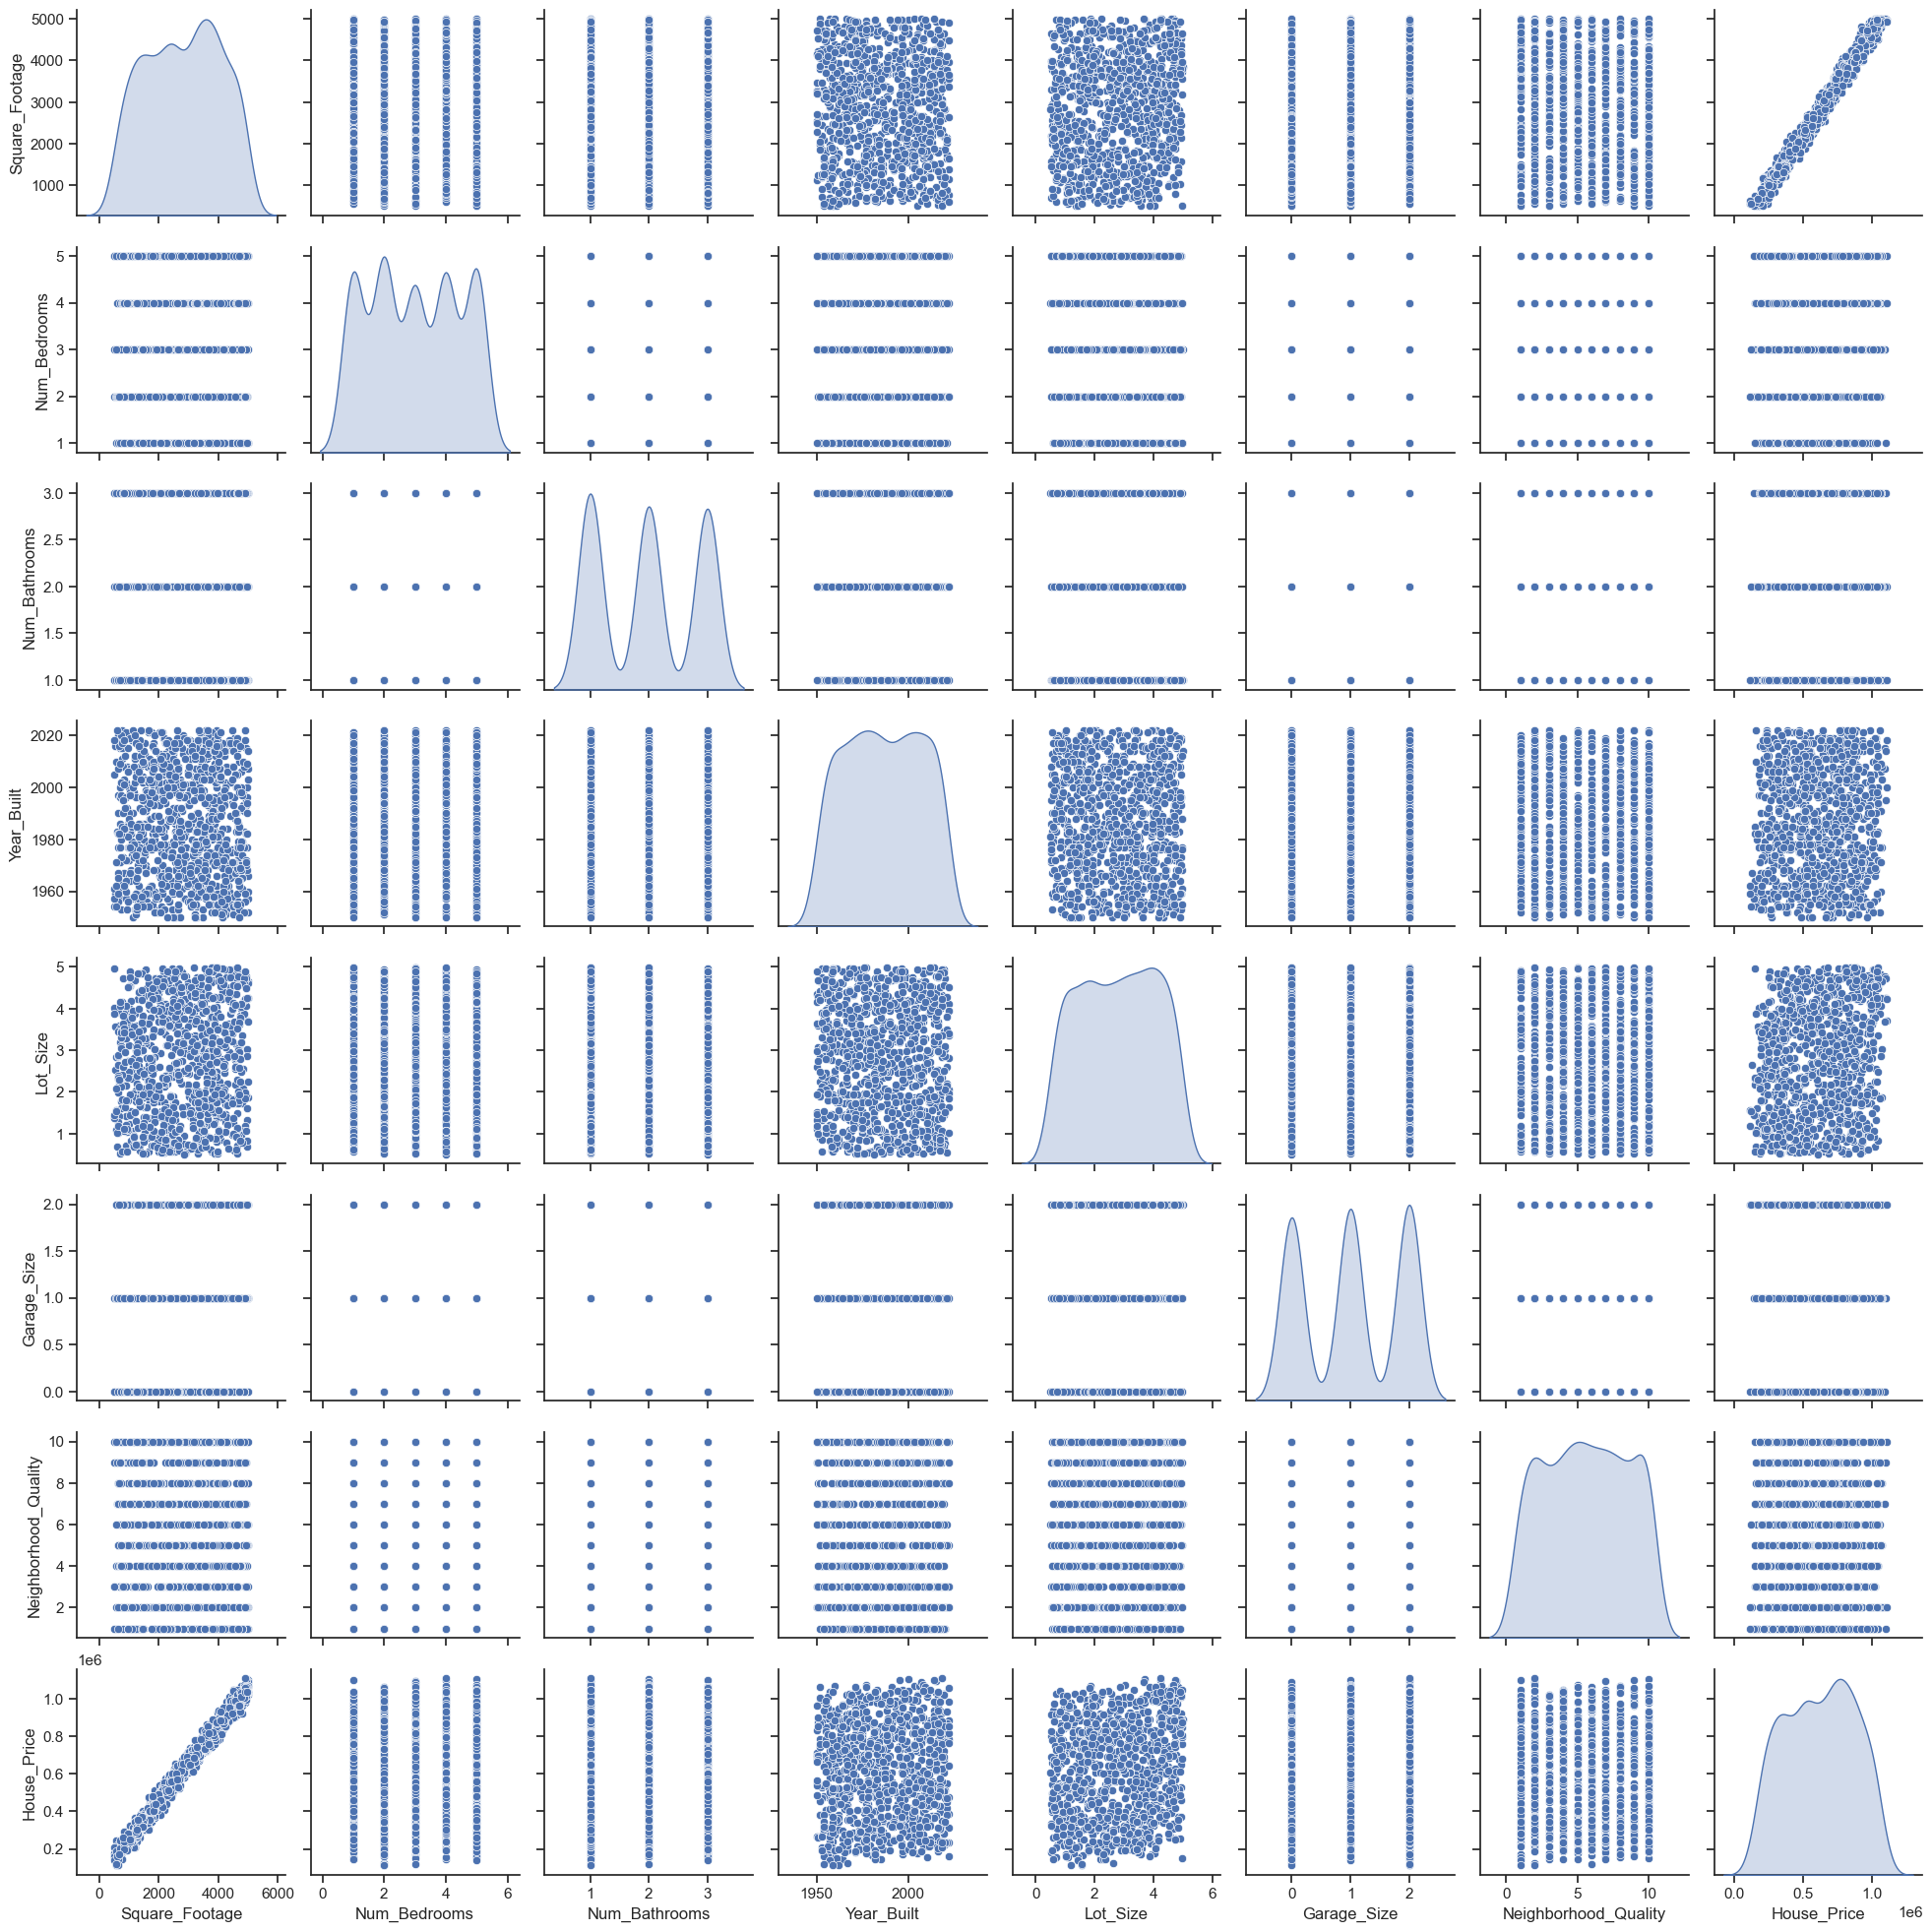

In [44]:
# if you have many features, select a subset: df_cont[['col1','col2','col3']]
sns.pairplot(df[['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price']], kind='scatter', diag_kind='kde', corner=False)
plt.show()

In [45]:
pearson = df[df_cont].corr(method='pearson')
spearman = df[df_cont].corr(method='spearman')

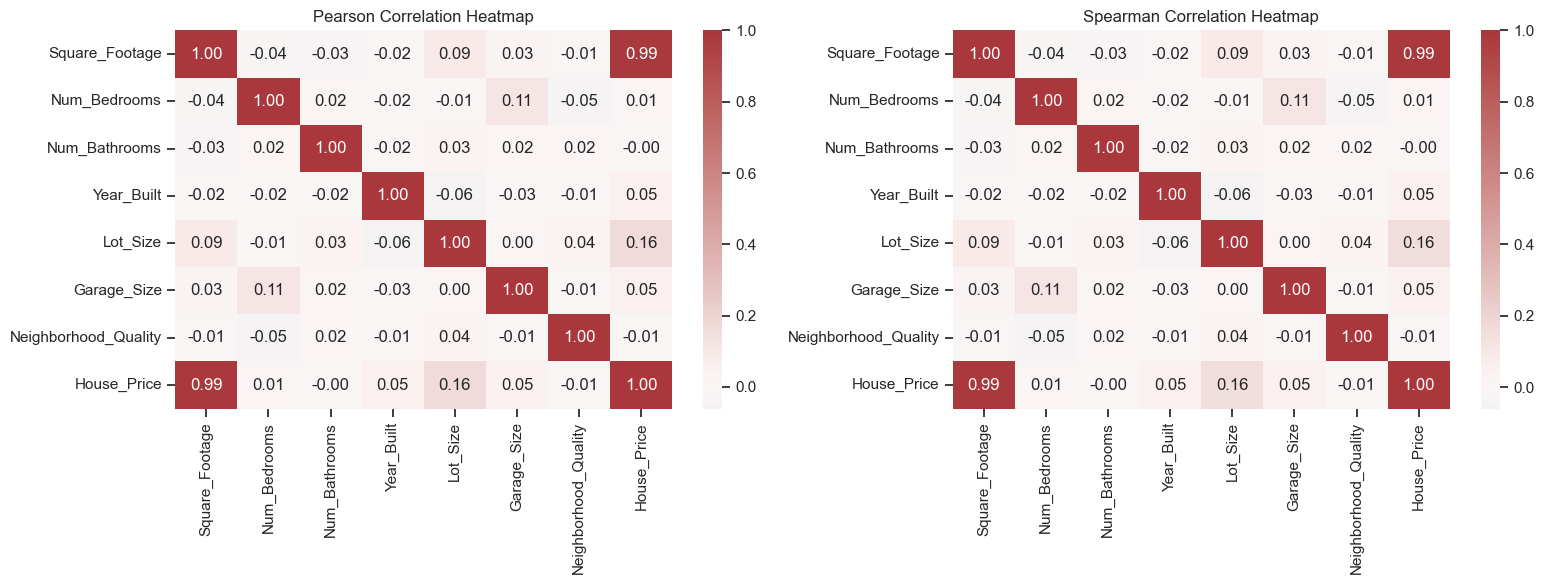

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pearson, annot=True, fmt=".2f", cmap='vlag', center=0, ax=axes[0])
axes[0].set_title("Pearson Correlation Heatmap")

sns.heatmap(spearman, annot=True, fmt=".2f", cmap='vlag', center=0, ax=axes[1])
axes[1].set_title("Spearman Correlation Heatmap")

plt.tight_layout()
plt.show()

In [47]:
import numpy as np
import pandas as pd

def top_pairs_with_sign(corr_df, top_n=10, strength_thresholds=(0.7, 0.3)):
    """
    Return top_n correlated feature pairs ordered by absolute correlation,
    but keep the signed correlation values and add Direction & Strength columns.
    
    Parameters:
      - corr_df: square correlation DataFrame (index and columns are feature names)
      - top_n: number of top unique pairs to return
      - strength_thresholds: tuple (strong_threshold, moderate_threshold)
           e.g. (0.7, 0.3) means:
             |r| >= 0.7 -> Strong
             0.3 <= |r| < 0.7 -> Moderate
             |r| < 0.3 -> Weak
    """

In [48]:
# remove self correlations by masking diagonal
corr_df=df.corr()
mask = ~np.eye(corr_df.shape[0], dtype=bool)
abs_corr = corr_df.abs().where(mask)

In [49]:
top_n = 5
stacked = abs_corr.unstack().dropna().sort_values(ascending=False)

unique_pairs = []
seen = set()

for (a, b), abs_val in stacked.items():
    # canonical key to avoid both (A,B) and (B,A)
    key = tuple(sorted((a, b)))
    if key in seen:
        continue
    seen.add(key)
    signed_val = corr_df.loc[a, b]  # real signed correlation
    unique_pairs.append((a, b, signed_val))
    if len(unique_pairs) >= top_n:
        break

In [50]:
df = pd.DataFrame(unique_pairs, columns=["Feature 1", "Feature 2", "Correlation"])
                  
def direction_label(x):
        if pd.isna(x):
            return "None"
        if x > 0:
            return "Positive"
        if x < 0:
            return "Negative"
            return "None"
df['Direction'] = df['Correlation'].apply(direction_label)

In [51]:
strength_thresholds = (0.7, 0.3) 

# 2. Your function definition
def strength_label(x):
    if pd.isna(x):
        return "None"
    ax = abs(x)
    if ax >= strong_th:
        return "Strong"
    if ax >= moderate_th:
        return "Moderate"
    if ax > 0:
        return "Weak"
    return "None"

# 3. Unpack the thresholds
strong_th, moderate_th = strength_thresholds

# 4. Apply the function to your DataFrame
df['Strength'] = df['Correlation'].apply(strength_label)

In [52]:
df['Abs Correlation'] = df['Correlation'].abs().round(3)

# 2. Reorder columns (rounding signed correlation)
df['Correlation'] = df['Correlation'].round(3)
df = df[['Feature 1', 'Feature 2', 'Correlation', 'Abs Correlation', 'Direction', 'Strength']]

# 3. View the final result
df

,Feature 1,Feature 2,Correlation,Abs Correlation,Direction,Strength
0,Square_Footage,House_Price,0.991,0.991,Positive,Strong
1,House_Price,Lot_Size,0.160,0.160,Positive,Weak
2,Garage_Size,Num_Bedrooms,0.114,0.114,Positive,Weak
3,Lot_Size,Square_Footage,0.089,0.089,Positive,Weak
4,Year_Built,Lot_Size,-0.061,0.061,Negative,Weak


In [53]:
top_pearson_signed = top_pairs_with_sign(pearson, top_n=10, strength_thresholds=(0.7, 0.3))
top_spearman_signed = top_pairs_with_sign(spearman, top_n=10, strength_thresholds=(0.7, 0.3))

print("Top Pearson (signed, with direction & strength):")
display(top_pearson_signed)

print("\nTop Spearman (signed, with direction & strength):")
display(top_spearman_signed)

Top Pearson (signed, with direction & strength):


None


Top Spearman (signed, with direction & strength):


None